In [1]:
from __future__ import annotations

In [2]:
import json
import tempfile
import zipfile
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

c:\Users\junhyun111\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\junhyun111\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\junhyun111\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorfl

In [3]:
# test.ipynb를 preprocessing 폴더에서 실행한다고 가정합니다.
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'test.csv'
BUNDLE_PATH = BASE_DIR / 'guard_bed_rnn_bundle.joblib'
MODEL_DIR = BASE_DIR / 'guard_bed_rnn_models'

print('BASE_DIR =', BASE_DIR)
print('DATA_PATH exists =', DATA_PATH.exists())
print('BUNDLE_PATH exists =', BUNDLE_PATH.exists())
print('MODEL_DIR exists =', MODEL_DIR.exists())


BASE_DIR = c:\Users\junhyun111\Desktop\psa\preprocessing
DATA_PATH exists = True
BUNDLE_PATH exists = True
MODEL_DIR exists = True


In [4]:
def strip_key(obj, key_to_remove: str):
    # 현재 keras 버전이 모르는 설정 키를 재귀적으로 제거합니다.
    if isinstance(obj, dict):
        return {
            key: strip_key(value, key_to_remove)
            for key, value in obj.items()
            if key != key_to_remove
        }
    if isinstance(obj, list):
        return [strip_key(item, key_to_remove) for item in obj]
    return obj


def load_keras_model_compat(model_path: Path) -> tf.keras.Model:
    # .keras 내부 config를 살짝 보정한 임시 파일로 모델을 로드합니다.
    with tempfile.TemporaryDirectory() as tmp_dir:
        temp_model_path = Path(tmp_dir) / model_path.name
        with zipfile.ZipFile(model_path) as src_zip:
            config = json.loads(src_zip.read('config.json'))
            config = strip_key(config, 'quantization_config')

            with zipfile.ZipFile(temp_model_path, 'w', compression=zipfile.ZIP_DEFLATED) as dst_zip:
                for member in src_zip.infolist():
                    if member.filename == 'config.json':
                        dst_zip.writestr('config.json', json.dumps(config))
                    else:
                        dst_zip.writestr(member, src_zip.read(member.filename))

        return tf.keras.models.load_model(temp_model_path, compile=False)


def build_sequence_arrays(df: pd.DataFrame, feature_cols: list[str], target_cols: list[str], sequence_length: int):
    # sample_id별 시계열을 묶고, 학습 때와 같은 길이의 시퀀스만 남깁니다.
    sequence_frames = {
        int(sample_id): seq.sort_values('time_h').reset_index(drop=True)
        for sample_id, seq in df.groupby('sample_id', sort=True)
    }

    valid_ids = [sample_id for sample_id, seq in sequence_frames.items() if len(seq) == sequence_length]
    removed_ids = [sample_id for sample_id, seq in sequence_frames.items() if len(seq) != sequence_length]

    if not valid_ids:
        raise ValueError(f'Expected sequence length {sequence_length} but no valid sequences were found.')

    x_list = []
    y_list = []
    frame_list = []
    for sample_id in valid_ids:
        seq = sequence_frames[sample_id]
        x_list.append(seq[feature_cols].to_numpy(dtype=np.float32))
        y_list.append(seq[target_cols].to_numpy(dtype=np.float32))
        frame_list.append(seq)

    x = np.stack(x_list).astype(np.float32)
    y = np.stack(y_list).astype(np.float32)
    return valid_ids, removed_ids, x, y, frame_list


def scale_3d(array_3d: np.ndarray, scaler) -> np.ndarray:
    # StandardScaler는 2차원 입력 기준이라 펼쳐서 스케일링한 뒤 원래 shape로 되돌립니다.
    n_samples, n_steps, n_features = array_3d.shape
    flat = array_3d.reshape(-1, n_features)
    scaled = scaler.transform(flat)
    return scaled.reshape(n_samples, n_steps, n_features).astype(np.float32)


def inverse_scale_3d(array_3d: np.ndarray, scaler) -> np.ndarray:
    n_samples, n_steps, n_features = array_3d.shape
    flat = array_3d.reshape(-1, n_features)
    restored = scaler.inverse_transform(flat)
    return restored.reshape(n_samples, n_steps, n_features)


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape_pct = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-9))) * 100.0
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'mape_pct': mape_pct}


In [5]:
# 번들에서 입력 컬럼, 타깃 컬럼, 스케일러, 시퀀스 길이를 가져옵니다.
bundle = joblib.load(BUNDLE_PATH)
feature_cols = bundle['feature_cols']
target_cols = bundle['target_cols']
sequence_length = bundle['sequence_length']
x_scaler = bundle['x_scaler']
y_scaler = bundle['y_scaler']

df = pd.read_csv(DATA_PATH).sort_values(['sample_id', 'time_h']).reset_index(drop=True)

required_cols = ['sample_id', 'time_h', *feature_cols, *target_cols]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f'Missing columns in test.csv: {missing_cols}')

print('test.csv shape:', df.shape)
print('target columns:', target_cols)
print('feature count:', len(feature_cols))
display(df.head())


c:\Users\junhyun111\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


test.csv shape: (66000, 49)
target columns: ['deltaP_future_kPa', 'friction_factor_future']
feature count: 45


,sample_id,bed_length_m,bed_diameter_m,particle_diameter_m,bed_porosity_0,particle_sphericity,flow_mol_s,T_in_C,P_in_kPa,RH_in,...,avg_liquid_hold_kg_m3,max_solid_load_kg_m3,max_liquid_hold_kg_m3,operating_time_h,filter_age_h,cleaning_count,time_since_last_cleaning_h,deltaP_future_kPa,friction_factor_future,d_deltaP_dt_kPa_h
0,1,1.324214,2.12672,0.012198,0.394107,0.874382,634.918854,48.299017,105.988933,0.592602,...,0.052235,0.059637,0.052235,0.016667,52.738714,9.0,0.112128,65.988933,11.025262,0.0
1,1,1.324214,2.12672,0.012198,0.394107,0.874382,634.918854,48.299017,105.988933,0.592602,...,0.104139,0.119276,0.104139,0.033333,52.755380,9.0,0.128795,65.988933,11.022458,0.0
2,1,1.324214,2.12672,0.012198,0.394107,0.874382,634.918854,48.299017,105.988933,0.592602,...,0.155715,0.178918,0.155715,0.050000,52.772047,9.0,0.145462,65.988933,11.019661,0.0
3,1,1.324214,2.12672,0.012198,0.394107,0.874382,634.918854,48.299017,105.988933,0.592602,...,0.206965,0.238563,0.206965,0.066667,52.788714,9.0,0.162128,65.988933,11.016873,0.0
4,1,1.324214,2.12672,0.012198,0.394107,0.874382,634.918854,48.299017,105.988933,0.592602,...,0.257890,0.298211,0.257890,0.083333,52.805380,9.0,0.178795,65.988933,11.014091,0.0


In [6]:
valid_ids, removed_ids, x_raw, y_true, sequence_frames = build_sequence_arrays(
    df=df,
    feature_cols=feature_cols,
    target_cols=target_cols,
    sequence_length=sequence_length,
)

x_scaled = scale_3d(x_raw, x_scaler)

print('usable sequence count:', len(valid_ids))
print('removed sequence count:', len(removed_ids))
print('x_raw shape:', x_raw.shape)
print('x_scaled shape:', x_scaled.shape)
print('y_true shape:', y_true.shape)
print('first sample_ids:', valid_ids[:10])


usable sequence count: 100
removed sequence count: 0
x_raw shape: (100, 660, 45)
x_scaled shape: (100, 660, 45)
y_true shape: (100, 660, 2)
first sample_ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [7]:
model_paths = sorted(MODEL_DIR.glob('*.keras'))
if not model_paths:
    raise FileNotFoundError(f'No .keras models found in {MODEL_DIR}')

predictions_by_model = {}
metrics_rows = []

for model_path in model_paths:
    model_name = model_path.stem.replace('_surrogate', '').upper()
    print(f'Loading {model_name}: {model_path.name}')

    model = load_keras_model_compat(model_path)
    y_pred_scaled = model.predict(x_scaled, verbose=0)
    y_pred = inverse_scale_3d(y_pred_scaled, y_scaler)

    predictions_by_model[model_name] = y_pred

    for target_idx, target_col in enumerate(target_cols):
        stats = regression_metrics(
            y_true[:, :, target_idx].ravel(),
            y_pred[:, :, target_idx].ravel(),
        )
        stats.update({
            'model': model_name,
            'target': target_col,
            'n_sequences': len(valid_ids),
            'sequence_length': sequence_length,
        })
        metrics_rows.append(stats)

metrics_df = pd.DataFrame(metrics_rows).sort_values(['target', 'rmse', 'model']).reset_index(drop=True)
display(metrics_df)


Loading GRU: gru_surrogate.keras
Loading LSTM: lstm_surrogate.keras


,rmse,mae,r2,mape_pct,model,target,n_sequences,sequence_length
0,1.395493,1.064579,0.995236,4.993761,GRU,deltaP_future_kPa,100,660
1,1.613290,1.145098,0.993633,5.132296,LSTM,deltaP_future_kPa,100,660
2,0.350618,0.242102,0.989167,2.048510,LSTM,friction_factor_future,100,660
3,0.371288,0.266843,0.987852,2.234413,GRU,friction_factor_future,100,660


In [8]:
# 특정 모델과 sample_id를 골라 실제값/예측값/오차를 표로 확인합니다.
selected_model = list(predictions_by_model.keys())[0]
selected_sample_id = valid_ids[0]

sample_idx = valid_ids.index(selected_sample_id)
sample_base = sequence_frames[sample_idx][['sample_id', 'time_h']].copy()
sample_pred = predictions_by_model[selected_model]

comparison_df = sample_base.copy()
for target_idx, target_col in enumerate(target_cols):
    comparison_df[f'{target_col}_actual'] = y_true[sample_idx, :, target_idx]
    comparison_df[f'{target_col}_pred'] = sample_pred[sample_idx, :, target_idx]
    comparison_df[f'{target_col}_error'] = sample_pred[sample_idx, :, target_idx] - y_true[sample_idx, :, target_idx]

print('selected_model =', selected_model)
print('selected_sample_id =', selected_sample_id)
display(comparison_df.head(20))


selected_model = GRU
selected_sample_id = 1


,sample_id,time_h,deltaP_future_kPa_actual,deltaP_future_kPa_pred,deltaP_future_kPa_error,friction_factor_future_actual,friction_factor_future_pred,friction_factor_future_error
0,1,0.000000,65.98893,63.426182,-2.562748,11.025262,11.420550,0.395288
1,1,0.016667,65.98893,67.717903,1.728973,11.022458,10.859848,-0.162610
2,1,0.033333,65.98893,68.091461,2.102531,11.019661,10.720960,-0.298701
3,1,0.050000,65.98893,67.975677,1.986748,11.016872,10.660557,-0.356316
4,1,0.066667,65.98893,67.860062,1.871132,11.014091,10.612902,-0.401190
5,1,0.083333,65.98893,67.719032,1.730103,11.011317,10.576884,-0.434433
6,1,0.100000,65.98893,67.576363,1.587433,11.008552,10.549195,-0.459356
7,1,0.116667,65.98893,67.389687,1.400757,11.005793,10.529634,-0.476158
8,1,0.133333,65.98893,67.217567,1.228638,11.003041,10.513937,-0.489104
9,1,0.150000,65.98893,67.061615,1.072685,11.000297,10.501868,-0.498428


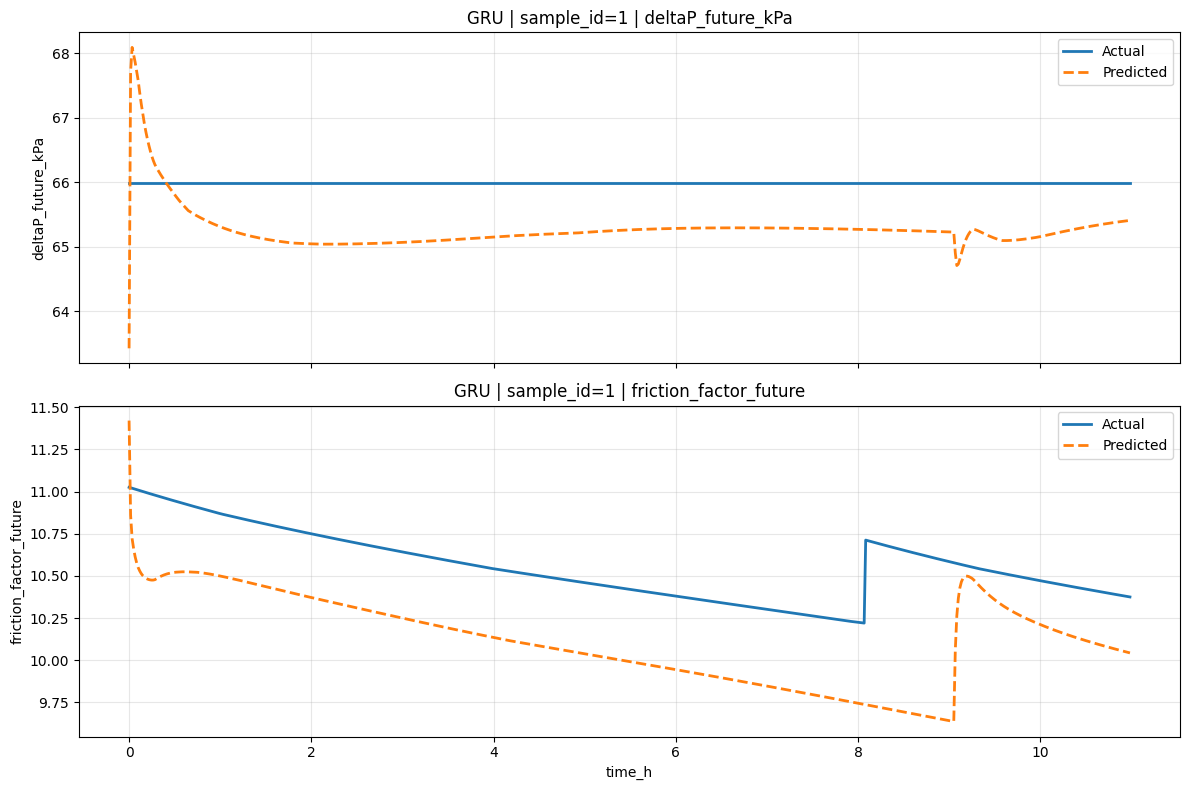

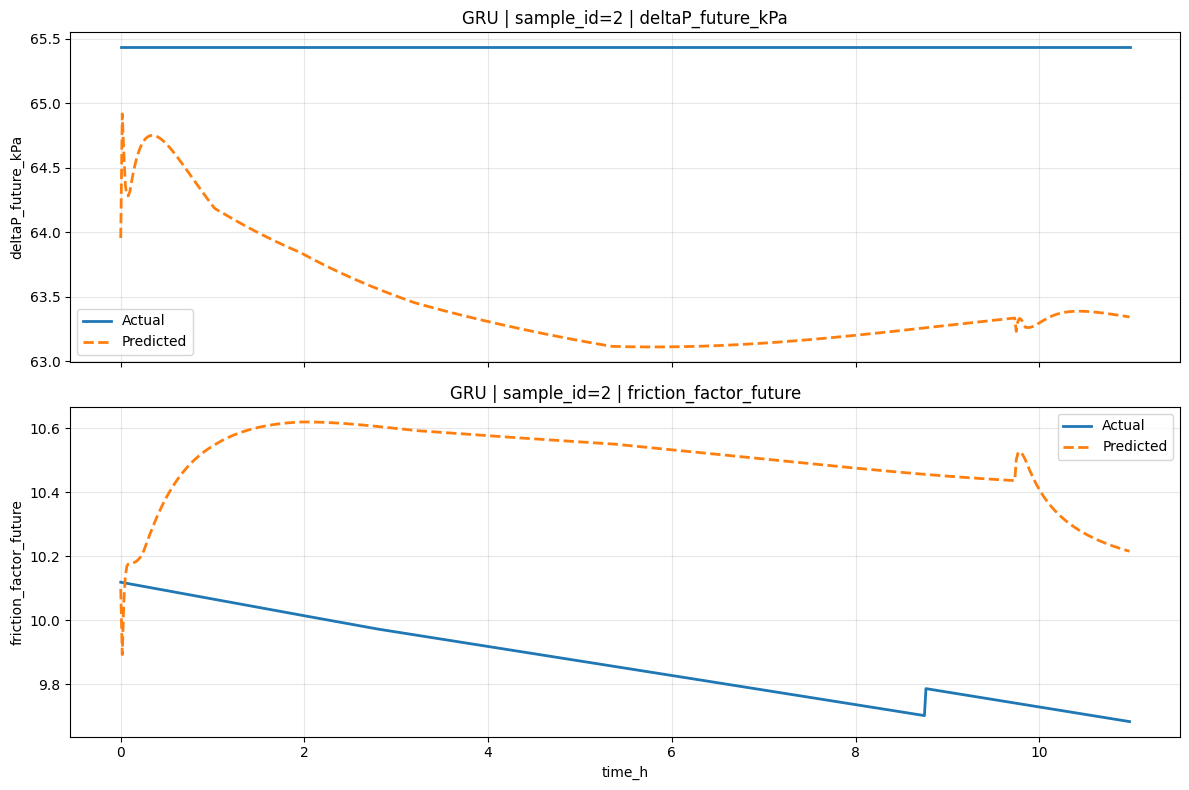

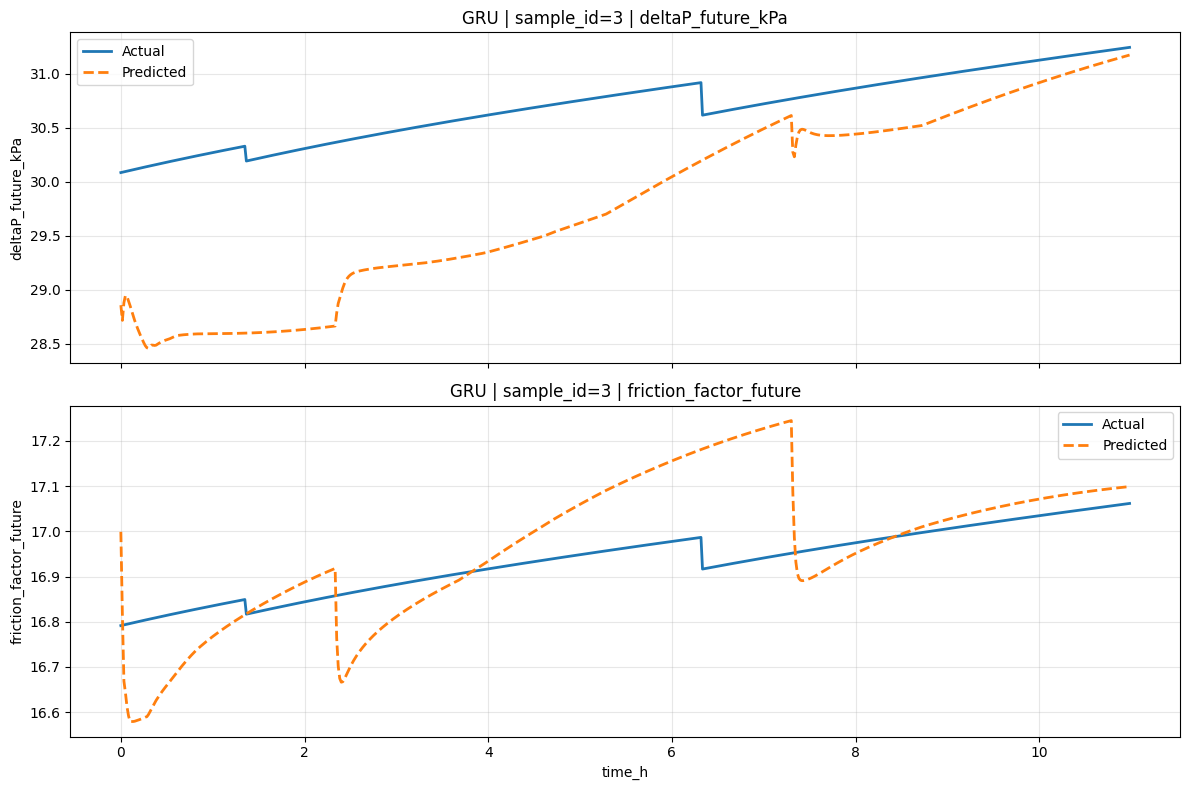

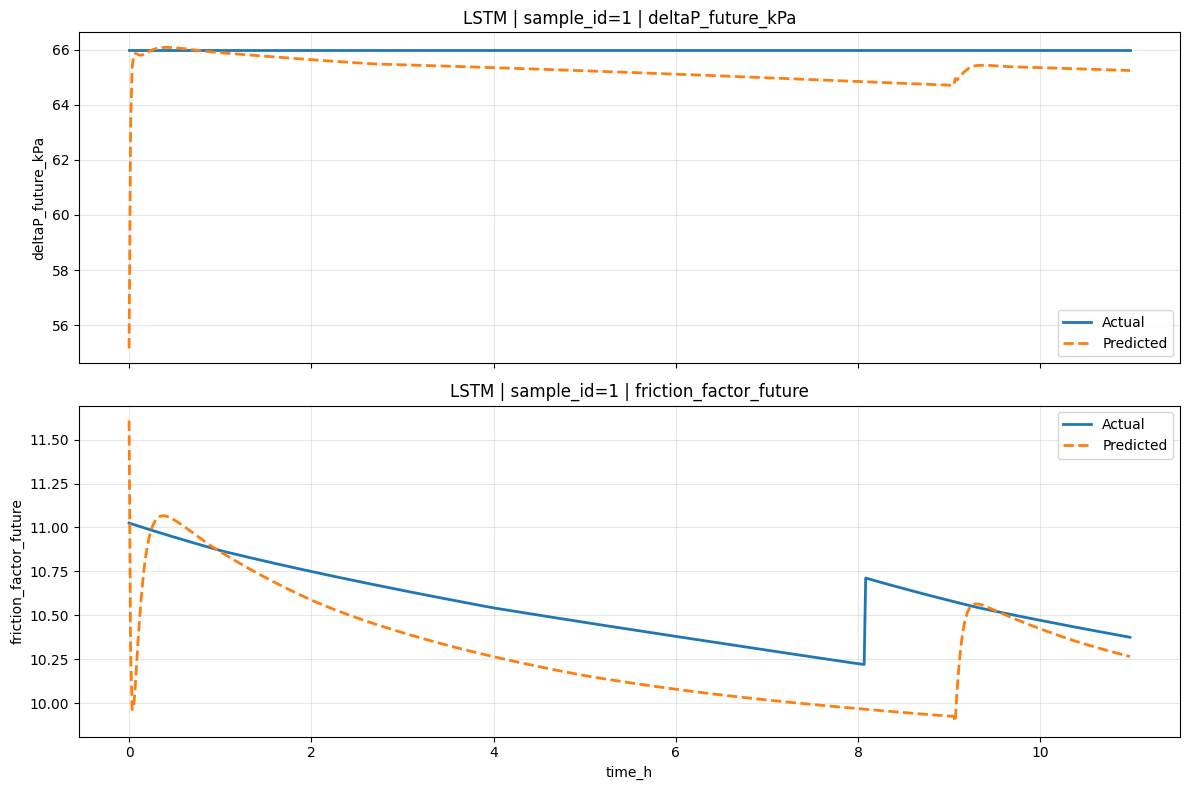

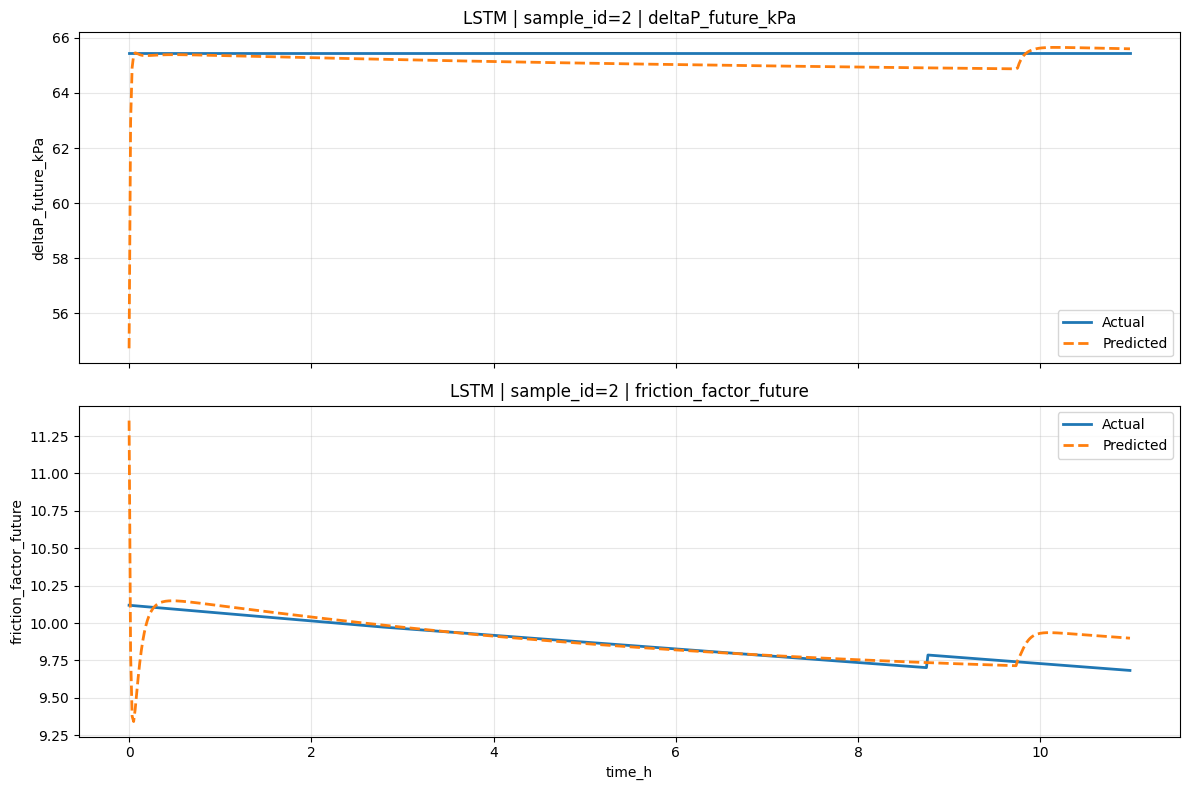

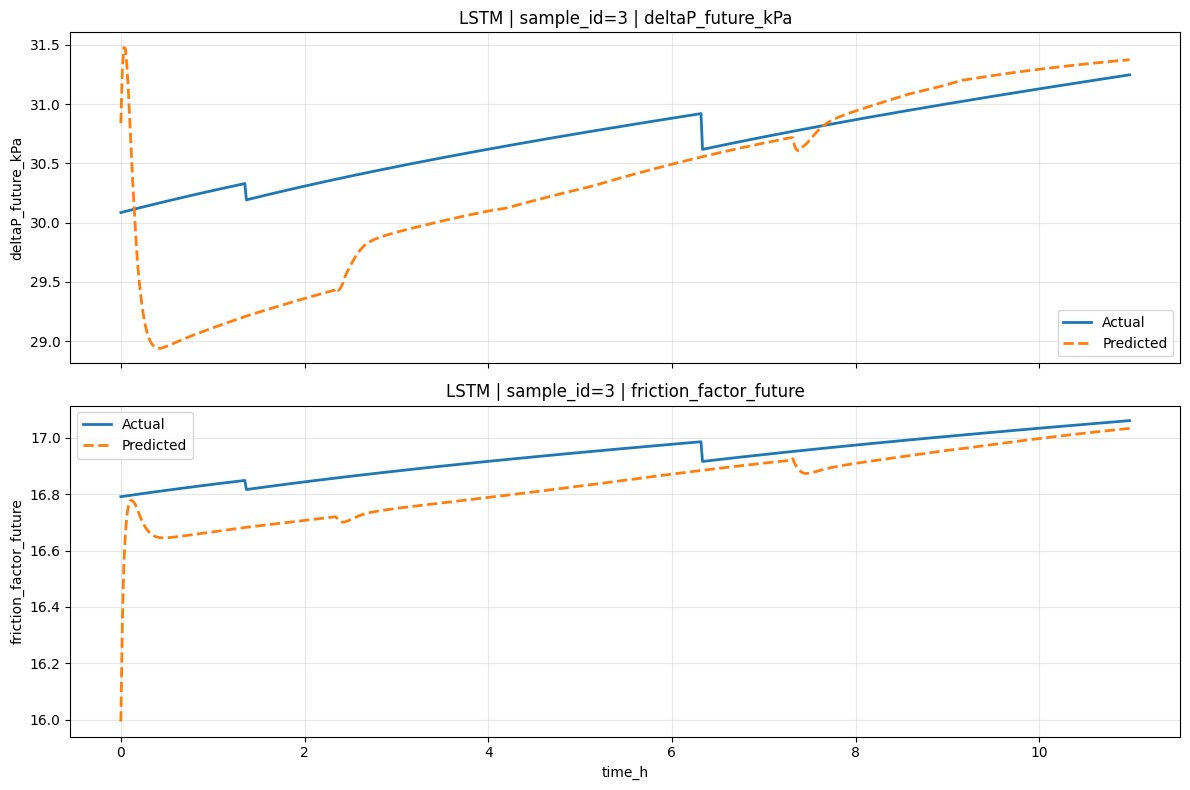

In [9]:
# 샘플 몇 개를 골라 실제값과 예측값을 커널에 바로 시각화합니다.
sample_ids_to_plot = valid_ids[:3]

for model_name, y_pred in predictions_by_model.items():
    for sample_id in sample_ids_to_plot:
        sample_idx = valid_ids.index(sample_id)
        sample_df = sequence_frames[sample_idx]

        fig, axes = plt.subplots(
            nrows=len(target_cols),
            ncols=1,
            figsize=(12, 4 * len(target_cols)),
            sharex=True,
        )
        if len(target_cols) == 1:
            axes = [axes]

        for ax, target_idx in zip(axes, range(len(target_cols))):
            target_col = target_cols[target_idx]
            ax.plot(sample_df['time_h'], y_true[sample_idx, :, target_idx], label='Actual', linewidth=2)
            ax.plot(sample_df['time_h'], y_pred[sample_idx, :, target_idx], label='Predicted', linewidth=2, linestyle='--')
            ax.set_title(f'{model_name} | sample_id={sample_id} | {target_col}')
            ax.set_ylabel(target_col)
            ax.grid(True, alpha=0.3)
            ax.legend()

        axes[-1].set_xlabel('time_h')
        fig.tight_layout()
        plt.show()
